# Biomarker S8 — Holdout một lần như báo cáo, không dùng k-fold

**Vì sao có notebook này bên cạnh S7.** S7 dùng cross-validation 15 fold, cho con số trung thực nhất
nhưng **mỗi ca được dự đoán bởi một mô hình khác nhau**, và không tồn tại "mô hình cuối cùng" nào để
đem đi làm việc khác. Nhiều ý tưởng tiếp theo lại cần đúng hai thứ mà k-fold không cho: *một* mô hình
đã huấn luyện, và *một* tập test cố định. S8 sinh ra cho việc đó.

**Chia dữ liệu giống hệt báo cáo 13/9:** `GroupShuffleSplit(test_size=0.2, random_state=42)` theo
`subject`. Cỡ tập test rơi vào khoảng 246 ca, đúng con số trong báo cáo, nên mọi bảng ở đây so trực
tiếp được với Bảng 5 và Bảng 6.

**Bảy kiến trúc** — sáu cái của S7, cộng **F** là cái mới:

| | Model | Đầu dự đoán |
|---|---|---|
| A | XGB softmax (= S4 gốc) | — |
| A2 | MLP softmax, đối chứng cho D | Linear |
| B | XGB Frank & Hall | — |
| C | XGB hồi quy + điểm cắt tối ưu QWK | — |
| D | MLP loss ngưỡng + L_mono | Linear |
| E | MLP đủ 4 thành phần loss của slide | Linear |
| **F** | **như E, nhưng đầu dự đoán là MLP** | **MLP 32→32→out** |
| **G** | **như E, nhưng ngưỡng dùng ASL thay BCE** | Linear |
| **H** | **như E, cộng ngưỡng quyết định `tau` học được** | Linear |
| **I** | **hai nhánh riêng cho bio và radiomics, gộp bằng α** | Linear |

Bốn cái cuối đều khác E **đúng một chỗ**, nên mỗi hiệu số đọc được như một đóng góp riêng lẻ.

**G, Asymmetric Loss.** Phân rã ngưỡng biến KL thành bài toán đa nhãn với bốn nhãn nhị phân, mà chúng
lệch rất khác nhau: `KL>0` có 77% dương, còn `KL>3` chỉ 8.6% dương, tức lệch 1:11. Đó đúng là triệu
chứng đã đo được — ca KL4 thật chỉ đạt trung bình 0.26 tới 0.38 ở ngưỡng cuối nên gần như không ai
được đoán là KL4. ASL với `gamma_neg > gamma_pos` hạ trọng số các âm dễ, tức đúng cái đang lấn át
ngưỡng cuối.

**H, ngưỡng học được.** Thêm tham số `tau` một chiều cho mỗi ngưỡng, giải mã thành `z_k > tau_k` thay
vì `p_k > 0.5`. Điểm mấu chốt: `tau` **không có gradient từ BCE**, vì BCE chỉ quan tâm từng ngưỡng
đúng hay sai, không quan tâm *tổng* của chúng có ra đúng lớp không. Nên phải thêm một thành phần loss
liên tục và khả vi của chính quy tắc giải mã:

    y_soft = Σ_k sigmoid((z_k − tau_k) / T)      và      MSE(y_soft, y)

**I, gộp theo nhóm đặc trưng.** `z = α·f_bio(x_bio) + β·f_rad(x_rad)` với `α + β = 1` được **bảo đảm
theo cấu trúc**: `α = sigmoid(gate)`, `β = 1 − α`, nên tổng luôn bằng 1 và không thể trôi ra ngoài.
Giá trị của nó không nằm ở kappa mà ở chỗ `α` **đọc được**: báo cáo 13/9 kết luận radiomics đóng góp
phần lớn mức tăng, nhưng đó là suy ra từ chênh lệch giữa hai mô hình. Ở đây `α` nói thẳng ra con số.

> Đọc `α` cẩn thận: nó là trọng số trên **biểu diễn đã học**, không phải tỉ lệ thông tin. Một nhánh
> có thể cho vector biên độ lớn hơn rồi bù lại bằng `α` nhỏ. Chỉ so `α` giữa các lần chạy cùng feature
> set, cùng seed, cùng số epoch.

> **S8 không thay thế S7.** Kappa của một lần chia dao động khoảng ±0.055, gấp bốn lần con số gộp
> out-of-fold của S7. Dùng S7 khi cần kết luận, dùng S8 khi cần một mô hình cố định.

## 0) Môi trường

In [10]:
# ============================================================
# Moi dinh nghia nam trong bsc/*.py - notebook chi goi.
# ============================================================
!pip install -q xgboost scikit-learn pandas matplotlib 2>/dev/null
from google.colab import drive
drive.mount("/content/drive")

REPO_URL, REPO_DIR = "https://github.com/AIVIETNAM-AIO-Tuan/bsCart-net.git", "/content/repo"
import os, sys
if not os.path.isdir(f"{REPO_DIR}/bsc"):
    !git clone -q $REPO_URL $REPO_DIR
!cd $REPO_DIR && git pull -q
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
for _m in [k for k in list(sys.modules) if k == "bsc" or k.startswith("bsc.")]:
    del sys.modules[_m]

import torch
from bsc import ordinal as ORD
from bsc.biomarkers import LEGACY_PREFIXES, SURFACE_PREFIXES
print("bsc.ordinal:", ORD.__file__, "| torch", torch.__version__)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
bsc.ordinal: /content/repo/bsc/ordinal.py | torch 2.11.0+cpu


## 1) Nạp bảng, tách 96 ca external, chọn feature set

Giống hệt S7. Nhãn tách external **luôn lấy lại từ manifest**, không tin cột trong bảng đặc trưng,
vì bảng S3 được sinh trước khi phép tách tồn tại.

In [11]:
from pathlib import Path
import json, time
import numpy as np, pandas as pd

BIOM_DIR = Path("/content/drive/MyDrive/OAI_seg/knee_biomarkers_09_09")
V2_CSV = BIOM_DIR / "s6_fcl" / "biomarker_table_v2.csv"
S3_CSV = BIOM_DIR / "biomarker_table.csv"
COMBINED_CSV = BIOM_DIR / "combined_features_table.csv"
OUT_DIR = BIOM_DIR / "s8_holdout"                     # MOI - khong dung chung voi s7_ordinal
OUT_DIR.mkdir(parents=True, exist_ok=True)
assert str(OUT_DIR).startswith("/content/drive/"), "Drive-first"

SRC = V2_CSV if V2_CSV.exists() else S3_CSV
assert SRC.exists(), f"khong thay {V2_CSV} lan {S3_CSV}"
df_all = pd.read_csv(SRC).drop_duplicates("case_id").reset_index(drop=True)
df_all = df_all.dropna(subset=["KL", "subject"]).copy()
df_all["KL"] = df_all["KL"].astype(int)

MANIFEST = BIOM_DIR / "cohort_manifest.csv"
SPLIT_COLS = ["source_dataset", "oaizib_split"]
man = pd.read_csv(MANIFEST).drop_duplicates("case_id")
have = [c for c in SPLIT_COLS if c in man.columns]
assert have, f"{MANIFEST.name} khong co cot danh dau external"
df_all = df_all.drop(columns=[c for c in have if c in df_all.columns], errors="ignore")
df_all = df_all.merge(man[["case_id"] + have], on="case_id", how="left")

is_ext = pd.Series(False, index=df_all.index)
if "source_dataset" in have:
    is_ext |= df_all["source_dataset"].astype(str).str.startswith("reserved_external_validation")
if "oaizib_split" in have:
    is_ext |= df_all["oaizib_split"].astype(str).str.contains("ext", case=False, na=False)
df = df_all[~is_ext].reset_index(drop=True)
print(f"tong {len(df_all)} | dung cho S8: {len(df)} | external giu rieng: {int(is_ext.sum())}")

legacy_cols = [c for c in df.columns if c.startswith(LEGACY_PREFIXES)]
surface_cols = [c for c in df.columns if c.startswith(SURFACE_PREFIXES)]
# Cung bo feature set voi S7 de hai notebook so duoc 1-1. `s6_surface_only` la bo QUAN
# TRONG nhat de tra loi "biomarker be mat MOT MINH manh den dau", dung bo qua.
FEATURE_SETS = {"legacy_s3": legacy_cols}
if surface_cols:
    FEATURE_SETS["s6_surface_only"] = surface_cols
    FEATURE_SETS["s6_all"] = legacy_cols + surface_cols
if COMBINED_CSV.exists():
    comb = pd.read_csv(COMBINED_CSV, low_memory=False).drop_duplicates("case_id")
    rad_cols = [c for c in comb.columns if c.startswith("rad_")]
    df = df.merge(comb[["case_id"] + rad_cols], on="case_id", how="left")
    FEATURE_SETS["s5_radiomics"] = legacy_cols + rad_cols
    if surface_cols:
        FEATURE_SETS["s6_all_plus_radiomics"] = legacy_cols + surface_cols + rad_cols
    print(f"nap {len(rad_cols)} cot radiomics")

# Nhan nhom dac trung cho nhanh fusion: TAT CA cot khong phai radiomics deu la "bio"
# (legacy hinh hoc + ho be mat cua S6). Mask nay di theo buoc chon dac trung o muc 4.
BIO_MASK = {fs: np.array([not c.startswith("rad_") for c in cols], bool)
            for fs, cols in FEATURE_SETS.items()}
print("ty le cot bio moi feature set:",
      {k: f"{v.sum()}/{len(v)}" for k, v in BIO_MASK.items()})

CLASSES = sorted(df["KL"].unique().tolist())
K = len(CLASSES)
y_idx = df["KL"].map({c: i for i, c in enumerate(CLASSES)}).to_numpy(np.int64)
groups = df["subject"].astype(str).to_numpy()
oa_target = (df["KL"] >= 2).to_numpy(np.float32)
print("so feature:", {k: len(v) for k, v in FEATURE_SETS.items()})
print("KL:", CLASSES, "| n moi lop:", np.bincount(y_idx, minlength=K).tolist())

tong 1229 | dung cho S8: 1229 | external giu rieng: 0
nap 856 cot radiomics
so feature: {'legacy_s3': 15, 's5_radiomics': 871}
KL: [0, 1, 2, 3, 4] | n moi lop: [284, 233, 295, 311, 106]


## 2) Chia holdout một lần — chọn giữa hai cách

`SPLIT_MODE` quyết định:

| | Cách chia | KL4 trong test |
|---|---|---|
| `"report"` | `GroupShuffleSplit(test_size=0.2, random_state=42)` — **đúng như báo cáo** | 21.6 ± 4.0 |
| `"stratified"` | `ORD.stratified_group_split` — phân tầng theo lớp **trên subject** | **21.0 ± 0.23** |

Cả hai đều chia theo `subject`, không ca nào của cùng một người lọt cả hai phía.

**Vì sao không dùng `StratifiedGroupKFold` của sklearn.** Nghe thì đúng việc, nhưng đo trên chính
cohort này nó cho **20.7 ± 4.0** ca KL4, tức gần như không cải thiện gì so với chia ngẫu nhiên. Trong
một lần chia 5 fold, số ca KL4 chạy từ 16 tới 25. Lý do là tiêu chí tham lam của nó lấy *trung bình*
độ lệch trên mọi lớp, nên lớp hiếm gần như không ảnh hưởng tới quyết định và bị hy sinh để cân bằng
các lớp lớn. Hàm trong `bsc/ordinal.py` gộp ca theo subject rồi phân tầng **trên subject**, nên vừa
giữ được tỉ lệ lớp vừa không tách ai ra hai phía.

**Phân tầng chỉ khử dao động, không làm KL4 nhiều hơn.** Con số vẫn quanh 21 vì cohort chỉ có 106 ca
KL4. Muốn nhiều hơn thì phải tăng `TEST_SIZE`, và đánh đổi bằng dữ liệu huấn luyện: 0.25 cho khoảng
26 ca, 0.30 cho khoảng 32 ca. Với 21 ca thì **mỗi ca đoán đúng hay sai đổi recall gần 5 điểm phần
trăm**, nên đừng so hai model dựa trên recall KL4 ở đây — dùng S7 cho việc đó.

In [12]:
SPLIT_MODE = "report"     # "stratified" = phan tang theo lop | "report" = giong bao cao
TEST_SIZE = 0.2
SPLIT_SEED = 42

if SPLIT_MODE == "report":
    from sklearn.model_selection import GroupShuffleSplit
    TR, TE = next(GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE,
                                    random_state=SPLIT_SEED).split(df, y_idx, groups))
else:
    TR, TE = ORD.stratified_group_split(y_idx, groups, test_size=TEST_SIZE, seed=SPLIT_SEED)

assert not (set(groups[TR]) & set(groups[TE])), "ro ri subject giua train va test"
df["split"] = np.where(np.isin(np.arange(len(df)), TE), "test", "train")
print(f"che do chia: {SPLIT_MODE} | train {len(TR)} ca / {len(set(groups[TR]))} subject "
      f"| test {len(TE)} ca / {len(set(groups[TE]))} subject")
print("bao cao 13/9 co n_test = 246")

dist = pd.DataFrame({"cohort": np.bincount(y_idx, minlength=K),
                     "train": np.bincount(y_idx[TR], minlength=K),
                     "test": np.bincount(y_idx[TE], minlength=K)},
                    index=[f"KL{c}" for c in CLASSES])
dist["test_%"] = (dist["test"] / dist["test"].sum() * 100).round(1)
dist["cohort_%"] = (dist["cohort"] / dist["cohort"].sum() * 100).round(1)
display(dist)

n4 = int(dist.loc[f"KL{CLASSES[-1]}", "test"])
print(f"lop hiem nhat co {n4} ca trong test -> moi ca doi recall {100 / max(n4, 1):.1f} diem %")
if n4 < 18:
    print("CANH BAO: qua it de noi bat cu dieu gi ve lop do. Dung so cua S7 thay the.")

# Ghim lai ngay: moi thu xay tiep phai DOC file nay thay vi chia lai, neu khong hai thi
# nghiem se khong so duoc voi nhau.
df[["case_id", "subject", "KL", "split"]].to_csv(OUT_DIR / "holdout_split.csv", index=False)
print("da ghim split vao holdout_split.csv")

che do chia: report | train 983 ca / 972 subject | test 246 ca / 243 subject
bao cao 13/9 co n_test = 246


,cohort,train,test,test_%,cohort_%
KL0,284,229,55,22.4,23.1
KL1,233,183,50,20.3,19.0
KL2,295,238,57,23.2,24.0
KL3,311,253,58,23.6,25.3
KL4,106,80,26,10.6,8.6


lop hiem nhat co 26 ca trong test -> moi ca doi recall 3.8 diem %
da ghim split vao holdout_split.csv


## 3) Bảy model — cùng train, cùng test

Siêu tham số giữ nguyên của S7 để so được. Chọn đặc trưng chạy **một lần trên tập train**, đúng theo
logic holdout: không có fold nào để chạy lại.

In [13]:
from xgboost import XGBClassifier, XGBRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupKFold, cross_val_predict

XGB_KW = dict(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
              colsample_bytree=0.8, random_state=42, n_jobs=2)
MLP_EPOCHS = 400
HEAD_HIDDEN_F = (32,)      # F: moi head la MLP 32 -> 32 -> out, thay vi mot Linear

def m_xgb_softmax(Xtr, ytr, Xte, **_):
    clf = XGBClassifier(objective="multi:softprob", num_class=K, eval_metric="mlogloss", **XGB_KW)
    clf.fit(Xtr, ytr)
    return dict(y_pred=clf.predict_proba(Xte).argmax(1), model=clf)

def m_xgb_frankhall(Xtr, ytr, Xte, **_):
    fh = ORD.FrankHall(lambda: XGBClassifier(objective="binary:logistic",
                                             eval_metric="logloss", **XGB_KW))
    fh.fit(Xtr, ytr, K)
    p = fh.predict_proba_thresholds(Xte)
    return dict(y_pred=ORD.decode_count(p), p_thr=p, y_alt=ORD.decode_cumdiff(p), model=fh)

def m_xgb_reg(Xtr, ytr, Xte, gtr=None, **_):
    reg = XGBRegressor(objective="reg:squarederror", **XGB_KW)
    inner = cross_val_predict(reg, Xtr, ytr, groups=gtr, cv=GroupKFold(n_splits=4))
    cuts = ORD.fit_cutpoints(inner, ytr, K)
    reg.fit(Xtr, ytr)
    return dict(y_pred=ORD.apply_cutpoints(reg.predict(Xte), cuts), cuts=cuts, model=reg)

def _mlp_runner(lambdas, decode, head_hidden=(), asl=None, learn_thr=False, fusion=False):
    def run(Xtr, ytr, Xte, oa_tr=None, bio_mask=None, **_):
        model, info = ORD.train_ordinal_mlp(
            Xtr, ytr, K, oa_target=oa_tr, lambdas=lambdas, epochs=MLP_EPOCHS, seed=0,
            head_hidden=head_hidden, asl=asl, learn_thresholds=learn_thr,
            bio_mask=bio_mask if fusion else None)
        out = ORD.predict_ordinal_mlp(model, info, Xte)
        r = dict(y_pred=out[decode], model=model, info=info,
                 tau=info.get("tau"), alpha=info.get("alpha"))
        if lambdas.get("ord", 0) > 0:
            r["p_thr"] = out["p_thr"]
            r["y_alt"] = out["y_softmax"] if lambdas.get("cls", 0) > 0 else out["y_cumdiff"]
        return r
    return run

MODELS = {
    "A_xgb_softmax":       m_xgb_softmax,
    "A2_mlp_softmax":      _mlp_runner(ORD.SOFTMAX_ONLY_LAMBDAS, "y_softmax"),
    "B_xgb_frankhall":     m_xgb_frankhall,
    "C_xgb_reg_cutpoints": m_xgb_reg,
    "D_mlp_ordinal_only":  _mlp_runner(ORD.ORDINAL_ONLY_LAMBDAS, "y_count"),
    "E_mlp_slide":         _mlp_runner(ORD.SLIDE_LAMBDAS, "y_count"),
    "F_mlp_slide_mlphead": _mlp_runner(ORD.SLIDE_LAMBDAS, "y_count", HEAD_HIDDEN_F),
    # G: doi BCE -> ASL o thanh phan nguong. Nham dung nguong cuoi, noi lech 1:11.
    "G_mlp_asl":           _mlp_runner(ORD.ASL_LAMBDAS, "y_count", asl=ORD.ASL_KW),
    # H: nguong quyet dinh la THAM SO HOC DUOC (tau), giai ma bang z_k > tau_k.
    "H_mlp_learned_thr":   _mlp_runner(ORD.LEARNED_THR_LAMBDAS, "y_count_tau", learn_thr=True),
    # I: hai nhanh rieng cho bio va radiomics, gop bang alpha + beta = 1.
    "I_mlp_fusion":        _mlp_runner(ORD.SLIDE_LAMBDAS, "y_count", fusion=True),
}
print("so model:", len(MODELS))

so model: 7


## 4) Chạy — một lần train, một lần test

In [14]:
SELECT_ABOVE = 120

rows, PRED, FITTED = [], {}, {}
t0 = time.time()
for fs_name, cols in FEATURE_SETS.items():
    X_all = df[cols].to_numpy(np.float32)
    imp = SimpleImputer(strategy="median").fit(X_all[TR])        # fit CHI tren train
    Xtr, Xte = imp.transform(X_all[TR]), imp.transform(X_all[TE])
    bmask = BIO_MASK[fs_name]
    if len(cols) > SELECT_ABOVE:
        keep = ORD.select_features(Xtr, y_idx[TR], seed=0)        # fit CHI tren train
        Xtr, Xte = Xtr[:, keep], Xte[:, keep]
        bmask = bmask[keep]                                       # mask di theo buoc chon
        print(f"{fs_name}: {len(cols)} -> {len(keep)} cot sau khi chon "
              f"({int(bmask.sum())} bio / {int((~bmask).sum())} radiomics)")
    for m_name, fn in MODELS.items():
        r = fn(Xtr, y_idx[TR], Xte, gtr=groups[TR], oa_tr=oa_target[TR], bio_mask=bmask)
        yp = np.asarray(r["y_pred"], np.int64)
        PRED[(fs_name, m_name)] = yp
        FITTED[(fs_name, m_name)] = r
        rows.append(dict(feature_set=fs_name, model=m_name, n_test=len(TE),
                         qwk=ORD.qwk(y_idx[TE], yp, K),
                         acc=float((yp == y_idx[TE]).mean()),
                         mae=ORD.mae(y_idx[TE], yp),
                         off_by_2=ORD.off_by_rate(y_idx[TE], yp, 2),
                         alpha=r.get("alpha")))
res = pd.DataFrame(rows)
res.to_csv(OUT_DIR / "holdout_metrics.csv", index=False)
print(f"xong trong {(time.time() - t0) / 60:.1f} phut")

s5_radiomics: 871 -> 95 cot sau khi chon
xong trong 1.4 phut


## 5) Kết quả — định dạng như Bảng 5 của báo cáo

`off_by_2` là tỉ lệ ca lệch từ 2 bậc KL trở lên, chính là cột mà báo cáo gọi là lỗi lâm sàng nghiêm
trọng nhất. Báo cáo đo được 22.0% cho S4 gốc, 9.3% cho nominal 93 cột, 7.3% cho Frank-Hall và 6.5%
cho Regression.

--- legacy_s3 (n_test=246)


,acc,qwk,mae,off_by_2
model,,,,
A_xgb_softmax,41.1,0.532,0.862,22.0
A2_mlp_softmax,43.5,0.594,0.805,18.7
B_xgb_frankhall,41.9,0.557,0.776,17.5
C_xgb_reg_cutpoints,38.2,0.604,0.837,18.7
D_mlp_ordinal_only,43.5,0.625,0.724,13.8
E_mlp_slide,43.5,0.611,0.732,14.2
F_mlp_slide_mlphead,46.7,0.608,0.728,16.7


--- s5_radiomics (n_test=246)


,acc,qwk,mae,off_by_2
model,,,,
A_xgb_softmax,50.8,0.753,0.589,8.9
A2_mlp_softmax,57.7,0.757,0.549,11.0
B_xgb_frankhall,52.4,0.776,0.537,6.1
C_xgb_reg_cutpoints,52.8,0.793,0.549,7.7
D_mlp_ordinal_only,55.3,0.792,0.520,6.9
E_mlp_slide,55.7,0.770,0.541,8.5
F_mlp_slide_mlphead,53.7,0.779,0.545,8.1


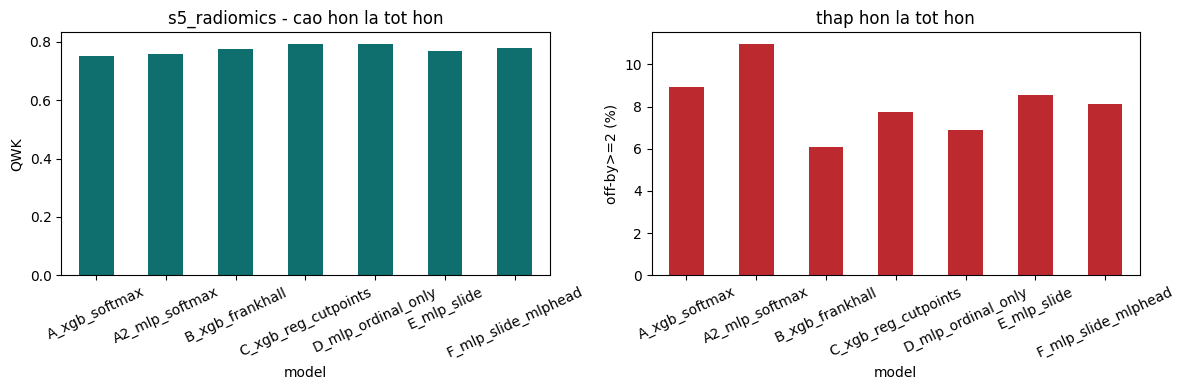

In [15]:
import matplotlib.pyplot as plt

for fs in FEATURE_SETS:
    sub = res[res.feature_set == fs].set_index("model")[["acc", "qwk", "mae", "off_by_2"]]
    print(f"--- {fs} (n_test={len(TE)})")
    display(sub.assign(acc=lambda d: (d.acc * 100).round(1),
                       off_by_2=lambda d: (d.off_by_2 * 100).round(1)).round(3))

fs0 = list(FEATURE_SETS)[-1]
sub = res[res.feature_set == fs0].set_index("model")
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sub["qwk"].plot.bar(ax=ax[0], rot=25, color="#0E6F6E")
ax[0].set_ylabel("QWK"); ax[0].set_title(fs0 + " - cao hon la tot hon")
(sub["off_by_2"] * 100).plot.bar(ax=ax[1], rot=25, color="#BC2A30")
ax[1].set_ylabel("off-by>=2 (%)"); ax[1].set_title("thap hon la tot hon")
plt.tight_layout(); plt.savefig(OUT_DIR / "holdout_metrics.png", dpi=130); plt.show()

## 6) Precision / Recall / F1 theo lớp + ma trận nhầm lẫn

So trực tiếp được với Bảng 6 của báo cáo, vì cùng cỡ tập test và cùng cách chia.

In [16]:
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

rows = []
for (fs, m_name), yp in PRED.items():
    pr, rc, f1, sup = precision_recall_fscore_support(
        y_idx[TE], yp, labels=list(range(K)), zero_division=0)
    for k in range(K):
        rows.append(dict(feature_set=fs, model=m_name, KL=str(CLASSES[k]), n=int(sup[k]),
                         precision=pr[k], recall=rc[k], f1=f1[k]))
    rows.append(dict(feature_set=fs, model=m_name, KL="macro", n=int(sup.sum()),
                     precision=pr.mean(), recall=rc.mean(), f1=f1.mean()))
per_class = pd.DataFrame(rows)
per_class.to_csv(OUT_DIR / "holdout_per_class.csv", index=False)

FS_SHOW = list(FEATURE_SETS)[-1]
sub = per_class[per_class.feature_set == FS_SHOW]
print("feature set dang hien:", FS_SHOW)
for metric in ["recall", "precision", "f1"]:
    print()
    print(metric.upper() + " theo lop (%)")
    display((sub.pivot(index="model", columns="KL", values=metric) * 100).round(1))

for m_name in ["A_xgb_softmax", "B_xgb_frankhall", "F_mlp_slide_mlphead"]:
    if (FS_SHOW, m_name) in PRED:
        print()
        print("confusion - " + m_name + " (hang = that, cot = doan)")
        print(confusion_matrix(y_idx[TE], PRED[(FS_SHOW, m_name)], labels=list(range(K))))

feature set dang hien: s5_radiomics

RECALL theo lop (%)


KL,0,1,2,3,4,macro
model,,,,,,
A2_mlp_softmax,69.1,34.0,50.9,75.9,53.8,56.7
A_xgb_softmax,65.5,26.0,47.4,69.0,34.6,48.5
B_xgb_frankhall,50.9,50.0,56.1,58.6,38.5,50.8
C_xgb_reg_cutpoints,56.4,56.0,38.6,46.6,84.6,56.4
D_mlp_ordinal_only,60.0,32.0,49.1,77.6,53.8,54.5
E_mlp_slide,58.2,34.0,49.1,79.3,53.8,54.9
F_mlp_slide_mlphead,52.7,30.0,52.6,74.1,57.7,53.4



PRECISION theo lop (%)


KL,0,1,2,3,4,macro
model,,,,,,
A2_mlp_softmax,58.5,48.6,53.7,57.9,87.5,61.2
A_xgb_softmax,67.9,32.5,42.2,53.3,64.3,52.0
B_xgb_frankhall,80.0,41.0,41.6,55.7,83.3,60.3
C_xgb_reg_cutpoints,68.9,36.8,43.1,65.9,66.7,56.3
D_mlp_ordinal_only,63.5,33.3,45.2,66.2,87.5,59.1
E_mlp_slide,58.2,36.2,50.9,62.2,93.3,60.2
F_mlp_slide_mlphead,60.4,33.3,43.5,64.2,88.2,57.9



F1 theo lop (%)


KL,0,1,2,3,4,macro
model,,,,,,
A2_mlp_softmax,63.3,40.0,52.3,65.7,66.7,57.6
A_xgb_softmax,66.7,28.9,44.6,60.2,45.0,49.1
B_xgb_frankhall,62.2,45.0,47.8,57.1,52.6,53.0
C_xgb_reg_cutpoints,62.0,44.4,40.7,54.5,74.6,55.3
D_mlp_ordinal_only,61.7,32.7,47.1,71.4,66.7,55.9
E_mlp_slide,58.2,35.1,50.0,69.7,68.3,56.2
F_mlp_slide_mlphead,56.3,31.6,47.6,68.8,69.8,54.8



confusion - A_xgb_softmax (hang = that, cot = doan)
[[36 10  9  0  0]
 [13 13 18  5  1]
 [ 3 14 27 13  0]
 [ 1  3 10 40  4]
 [ 0  0  0 17  9]]

confusion - B_xgb_frankhall (hang = that, cot = doan)
[[28 19  8  0  0]
 [ 5 25 18  2  0]
 [ 2 14 32  9  0]
 [ 0  3 19 34  2]
 [ 0  0  0 16 10]]

confusion - F_mlp_slide_mlphead (hang = that, cot = doan)
[[29 17  9  0  0]
 [14 15 18  3  0]
 [ 5 11 30 11  0]
 [ 0  2 11 43  2]
 [ 0  0  1 10 15]]


## 7) Bốn biến thể so với E — mỗi cái đổi đúng một chỗ

`F`, `G`, `H`, `I` đều lấy E làm gốc và thay đúng một thành phần, nên mỗi hiệu số đọc được như đóng
góp riêng của thành phần đó. Chênh lệch nhỏ hơn dao động của một lần chia, khoảng ±0.055 QWK, thì
chưa kết luận được gì.

Bảng `alpha` ở cuối là thứ mà kappa không nói được: mô hình tự chọn dựa vào biomarker hình học bao
nhiêu phần so với radiomics.

In [17]:
BASE = "E_mlp_slide"
VARIANTS = {"F_mlp_slide_mlphead": "head MLP thay Linear",
            "G_mlp_asl":           "ASL thay BCE o nguong",
            "H_mlp_learned_thr":   "nguong tau hoc duoc",
            "I_mlp_fusion":        "hai nhanh bio/radiomics"}
NOISE = 0.055     # dao dong cua MOT lan chia

cmp = res.pivot(index="feature_set", columns="model", values="qwk")
rows = []
for m, mo_ta in VARIANTS.items():
    if m not in cmp.columns:
        continue
    for fs in cmp.index:
        d = cmp.loc[fs, m] - cmp.loc[fs, BASE]
        rows.append(dict(bien_the=m, doi_gi=mo_ta, feature_set=fs,
                         E=round(cmp.loc[fs, BASE], 3), bien_the_qwk=round(cmp.loc[fs, m], 3),
                         hieu=round(d, 3), vuot_nhieu="co" if abs(d) > NOISE else "khong"))
delta = pd.DataFrame(rows)
print(f"Moi bien the khac E DUNG MOT CHO. Dao dong cua mot lan chia ~{NOISE}.")
display(delta)

n_vuot = int((delta.vuot_nhieu == "co").sum())
print(f"{n_vuot}/{len(delta)} hieu so vuot nguong nhieu"
      + ("" if n_vuot else " -> KHONG bien the nao ket luan duoc tren mot lan chia"))

# alpha cua nhanh fusion
al = res[res.alpha.notna()][["feature_set", "model", "alpha", "qwk"]]
if len(al):
    print()
    print("alpha = trong so nhanh BIOMARKER (1 - alpha la radiomics):")
    display(al.assign(alpha=lambda d: d.alpha.round(3),
                      beta=lambda d: (1 - d.alpha).round(3)).round(3))

,E (head Linear),F (head MLP),F - E
feature_set,,,
legacy_s3,0.611,0.608,-0.003
s5_radiomics,0.770,0.779,0.010


chenh lech lon nhat 0.010 | dao dong cua mot lan chia ~0.055 -> CHUA ket luan duoc


## 8) Lưu model và cấu hình

In [19]:
import pickle

ok, fail = {}, {}
for fs, m in FITTED:
    obj = FITTED[(fs, m)].get("model")
    try:
        pickle.dumps(obj)
        ok[f"{fs}__{m}"] = obj
    except Exception as e:
        fail[f"{fs}__{m}"] = repr(e)[:90]
with open(OUT_DIR / "fitted_models.pkl", "wb") as f:
    pickle.dump(ok, f)
print(f"luu duoc {len(ok)} model")
for k, v in fail.items():
    print("   KHONG luu duoc:", k, "->", v)


luu duoc 12 model
   KHONG luu duoc: legacy_s3__B_xgb_frankhall -> AttributeError("Can't get local object 'm_xgb_frankhall.<locals>.<lambda>'")
   KHONG luu duoc: s5_radiomics__B_xgb_frankhall -> AttributeError("Can't get local object 'm_xgb_frankhall.<locals>.<lambda>'")


## Ghi chú

- **S8 không thay thế S7.** Con số của một lần chia dao động khoảng ±0.055 QWK, gấp bốn lần con số gộp
  out-of-fold của S7. Dùng S7 để kết luận, dùng S8 khi cần một mô hình cố định và một tập test cố định.
- `holdout_split.csv` ghim lại ca nào train ca nào test. Mọi thứ xây tiếp nên **đọc file đó** thay vì
  chia lại, nếu không hai thí nghiệm sẽ không so được với nhau.
- F khác E đúng một chỗ là head sâu hơn. Nếu F không hơn E thì đó là một kết luận đáng ghi: trên bảng
  biomarker, làm đầu dự đoán sâu hơn không giúp gì.
- Chưa làm ở đây: **trích latent vector**. Ý tưởng đó đến từ mô hình phân loại ảnh, mà nhánh ảnh thì
  chưa có. Khi nào có encoder ảnh thì mới bàn tiếp.